In [1]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

I0000 00:00:1791274666.938896    4103 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791274666.941472    4103 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791274667.339644    4103 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791274669.253925    4103 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [ ]:
(xtrain,ytrain),(xtest,ytest) = datasets.cifar10.load_data()



In [4]:
xtrain.shape

(50000, 32, 32, 3)

In [5]:
xtest.shape

(10000, 32, 32, 3)

In [6]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','shi p','truck']

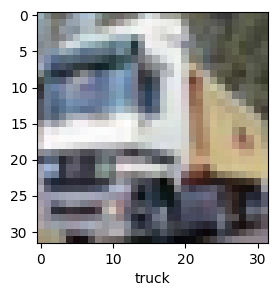

In [13]:

def plot_sample(x,y,index):
    plt.figure(figsize=(3,3))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index][0]])
    plt.show()
plot_sample(xtrain,ytrain,1)

In [14]:
xtrain = xtrain/255 
xtest = xtest/255

In [17]:
cnn = models.Sequential([
      #feature extraction
     layers.Conv2D(filters=32,activation='relu',kernel_size = (3,3),input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=64,activation='relu',kernel_size = (3,3),input_shape =(32,32,3)),
     layers.MaxPooling2D((2,2)),
       #classification
        layers.Flatten(),
         layers.Dense(64,activation='relu'),
       layers.Dense(10,activation='softmax')])

cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
cnn.fit(xtrain,ytrain,epochs=20)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4667 - loss: 1.4860
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5969 - loss: 1.1450
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6436 - loss: 1.0198
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6739 - loss: 0.9381
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6986 - loss: 0.8722
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7166 - loss: 0.8238
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7295 - loss: 0.7775
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7441 - loss: 0.7386
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7548 - loss: 0.7048
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7637 - loss: 0.6763
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7744 - loss: 0.6496
Epoch 12/20
1563/1563 ━━━━━━━━

In [18]:
ypred=cnn.predict(xtest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [19]:
cnn.evaluate(xtest,ytest)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6870 - loss: 1.1042


[1.1041699647903442, 0.6869999766349792]

In [20]:
ytest=ytest.reshape(-1,) 
ypred=cnn.predict(xtest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [21]:
yclasses=[np.argmax(element) for element in ypred] 
print('classification report:\ n',classification_report(ytest,yclasses))

classification report:\ n               precision    recall  f1-score   support

           0       0.74      0.70      0.72      1000
           1       0.85      0.77      0.81      1000
           2       0.60      0.56      0.58      1000
           3       0.54      0.52      0.53      1000
           4       0.55      0.70      0.62      1000
           5       0.65      0.54      0.59      1000
           6       0.75      0.74      0.74      1000
           7       0.66      0.77      0.71      1000
           8       0.82      0.81      0.81      1000
           9       0.75      0.76      0.76      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000

